In [1]:
!pip install opencv-python-headless matplotlib Pillow


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
from io import BytesIO

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

print("✅ Face and Eye detector loaded successfully!")

✅ Face and Eye detector loaded successfully!


In [4]:
print("Upload an image 👇")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
image = Image.open(BytesIO(uploaded[filename])).convert("RGB")
img = np.array(image)
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 3)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=5, minSize=(20, 20))
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (255, 0, 0), 2)

print(f"✅ Detection complete!")
print(f"👤 Total faces detected: {len(faces)}")

Upload an image 👇


Saving b3c4ea6d012855750f2d070d4d46805e.webp to b3c4ea6d012855750f2d070d4d46805e.webp
✅ Detection complete!
👤 Total faces detected: 2


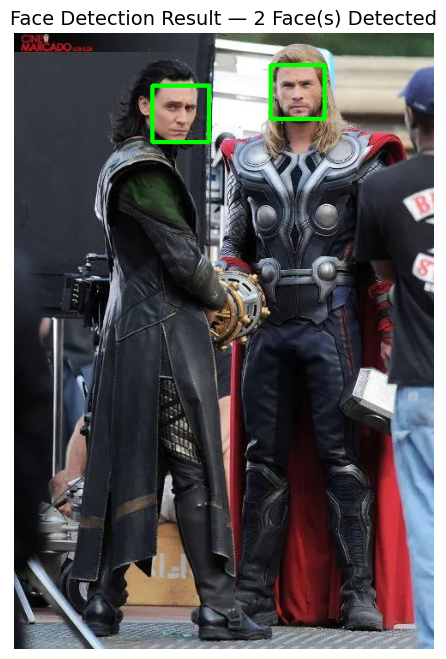

👤 FACE DETECTION RESULTS
Face 1: Position — X:299, Y:37 | Size — 63x63 pixels
Face 2: Position — X:161, Y:61 | Size — 66x66 pixels


In [6]:
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f"Face Detection Result — {len(faces)} Face(s) Detected", fontsize=14)
plt.show()

print("="*40)
print("👤 FACE DETECTION RESULTS")
print("="*40)
for i, (x, y, w, h) in enumerate(faces, 1):
    print(f"Face {i}: Position — X:{x}, Y:{y} | Size — {w}x{h} pixels")
print("="*40)